In [11]:
import urllib.request
from bs4 import BeautifulSoup
import pandas as pd
import os
import time as ti
import random
import traceback
from IPython.display import clear_output
import seaborn as sns

from datetime import datetime, timedelta

In [12]:
#Define function to calculate the absolute date from a relative date that google maps gives
#Loses resolution as the date goes past a year
def convert_date(relative_date, file_date):
    date_array = relative_date.split()
    file_date_array = file_date.split('/')
    match date_array[1]:
        case 'day' | 'days':

            if date_array[0]=='a':
                days = 1
            else:
                days = int(date_array[0])
            
            date = datetime(int(file_date_array[0]),int(file_date_array[1]),int(file_date_array[2]))
            entry_date = date - timedelta(days=days)
        case 'week' | 'weeks':

            if date_array[0]=='a':
                days = 1 * 7
            else:
                days = int(date_array[0]) * 7
            
            date = datetime(int(file_date_array[0]),int(file_date_array[1]),int(file_date_array[2]))
            entry_date = date - timedelta(days=days)
        case 'month' | 'months':

            if date_array[0]=='a':
                days = 1 * 30
            else:
                days = int(date_array[0]) * 30
            
            date = datetime(int(file_date_array[0]),int(file_date_array[1]),int(file_date_array[2]))
            entry_date = date - timedelta(days=days)
        case 'year' | 'years':

            if date_array[0]=='a':
                days = 1 * 365
            else:
                days = int(date_array[0]) * 365
                
            date = datetime(int(file_date_array[0]),int(file_date_array[1]),int(file_date_array[2]))
            entry_date = date - timedelta(days=days)
        case _:

            date = datetime(int(file_date_array[0]),int(file_date_array[1]),int(file_date_array[2]))
            entry_date = date
        
    return entry_date

# 1 - Data Collection
### Can skip if already have dat or using existing data set

In [2]:
airports = pd.read_csv('locations.csv')
urls = airports['URL'].tolist()
max_fails = 10
filenames = airports['FAA'].tolist()
is_finished = airports['checked'].tolist()

# 1.1 - Data Collection Scraping
### Is run single threaded to not overload the host, will take time if using for new places

#### Google place ID is needed, this loop handles paginated reviews. Images are gathered but are not saved.

In [ ]:
for n,url in enumerate(urls):
    
    next_page_token = ''
    
    url = url.split('!1s')[1]
    place_id = url.split('!')[0]

    d1=[] #Text Reviews
    d2=[] #Review Score
    d3=[] #Review Date
    d4=[]
    # Open review information

    
    
    if is_finished[n]==0:
        print(filenames[n] + " is Starting!")
        while True:
            target_url = "https://www.google.com/async/reviewDialog?hl=en&async=feature_id:" + place_id + ",sort_by:newestFirst,next_page_token:" + next_page_token + ",associated_topic:,_fmt:pc"

            txt = urllib.request.urlopen(target_url).read()
        
            response = BeautifulSoup(txt, 'html.parser')
            successful = False
            fails = 0
            
            while successful!=True:
                try:
                    response_text = str(response)
                    # Find the token to access the next page of reviews
                    response_text = response_text.split("data-next-page-token",1)[1]
                    response_text = response_text.split('"',1)[1]
                    if(next_page_token!=response_text.split('"',1)[0]):
                        next_page_token = response_text.split('"',1)[0]
                        successful=True
                    else:
                        fails+=1
                        print("Failed, retrying")
                        
                    if fails==max_fails:
                        print("Failed after 10 tries exiting")
                        break
                except:
                        pass
                    
                #If the no. of fails exceeds n times then exit loop of trying to grab reviews
                if fails==max_fails:
                    break
            
            for i,node in enumerate(response.findAll('div',{"class": "Jtu6Td"})):
                # Find the review text 
                re = (''.join(node.findAll(string=True, )))
                review = re
                #remove extra fluff text for the 'more' blurb that conceals the review
                if(len(review)>40):
                    review = review[:40] + review.split(review[:40])[1]
                    
                #Grab every other node, 10 reviews means 10 junk entriesd for 20 total entries.
                #Junk entries are just doubles that occur immediately after the real entry (i.e. Review 1 is i=0 & i=1, Review 2 is i=2 & i=3)
                
                if(i%2==0):
                    d1.append(review)
            for i,node in enumerate(response.findAll('span',{"class": "lTi8oc z3HNkc"})):
                # Find the rating of the review
                node = str(node)
                rating = int(node.split('"')[1].split()[1][0])
                if(i%2==0):
                    d2.append(rating)
                
            for i,node in enumerate(response.findAll('span',{"class": "dehysf lTi8oc"})):
                # Find the time the review was submitted
                node = str(node)
                time = node.split('>')[1].split('<')[0]
                
                if(i%2==0):
                    d3.append(time)
            if(len(d1)%20==0):
                clear_output(wait=True)
                print("Airport: ",filenames[n], " | Progress: " + str(len(d1)) + " reviews")
                print("Airport no: ",str(n), " of " + str(len(url)) + " airports")
            
            if next_page_token=="" :
                break
        df = pd.DataFrame()
        df['Review Text'] = d1
        df['Score'] = d2
        df['Date'] = d3(consider a smaller or optimized model)
        df.to_csv(filenames[n]+'.csv')
        is_finished[n] = 1
        airports['checked']=is_finished
        airports.to_csv('locations.csv')
    else:
        print(filenames[n] + " is finished!")

Airport:  SJC  | Progress: 7620 reviews
Airport no:  35  of 69 airports
OAK is finished!
MSY is finished!
RDU is finished!
SMF is finished!
MCI is finished!
SNA is finished!
SAT is finished!
CLE is finished!
PIT is finished!
IND is finished!
RSW is finished!
CVG is finished!
SJU is finished!
CMH is finished!
OGG is finished!
MKE is finished!
BDL is finished!
PBI is finished!
JAX is finished!
BUR is finished!
ABQ is finished!
ANC is finished!
ONT is finished!
OMA is finished!
MEM is finished!
CHS is finished!
RNO is finished!
BOI is finished!


# 1.2 - Data Pre-proccessing

In [5]:
current_path = os.getcwd()
in_folder = "\\raw data"
df = pd.DataFrame()
for file in os.listdir(current_path+in_folder):
    temp_df = pd.read_csv(current_path+in_folder+"\\"+file)
    dates = []
    file_date = os.path.getmtime(current_path+in_folder+"\\"+file)
    file_date = datetime.fromtimestamp(file_date).strftime('%Y/%m/%d')
    for rdate in temp_df['Date']:
        dates.append(convert_date(rdate, file_date))
    temp_df['Date'] = dates
    temp_df['Airport'] = file.split('.')[0]
    df = pd.concat([df,temp_df],ignore_index=True)
len(df)

1208456

# 2 - Zero Shot Classification

In [6]:
#Import transformers and pipelining libraries to allow use of LLMs and GPU acceleration
from transformers import pipeline
import torch

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()
#Additional Info when using cuda
if device.type == 'cuda': 
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda

NVIDIA GeForce RTX 2070 SUPER
Memory Usage:
Allocated: 1.5 GB
Cached:    1.5 GB


In [ ]:
# Load a zero-shot classification model
# MNLI BART model runs well on a variety of topics
#Zero shot classification pipeline autogenerates the hypothesis prompts for the model to test
classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli', device=device)

C:\Users\McCulloughStevenTann\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
# Define candidate labels
candidate_labels = ['Person has a disability', 'Disability Status Unknown','Person does not has a disability']

In [9]:
# Function to classify text in batches
def classify_texts(texts, candidate_labels, classifier):
    results = classifier(texts, candidate_labels, multi_label=False)
    labels = [result['labels'][0] for result in results]
    scores = [result['scores'][0] for result in results]
    return labels, scores

In [2]:
def printProgressBar (iteration, total, prefix = '', suffix = '', decimals = 1, length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    clear_output(wait=True)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [ ]:
#Dropping text shorter than 20 characters
df = df[df['Review Text'].str.len()>20]
df=df.reset_index(drop=True)
df['Review Text'] = df['Review Text'].astype('string')
df

,Unnamed: 0,Review Text,Score,Date,Airport,disability,disability_confidence,category
0,0,Can t afford air conditioning anymore. Always...,3,2024-09-30,ABQ,None,None,nan
1,1,Views out the windows os great with the mount...,3,2024-09-30,ABQ,None,None,nan
2,2,Airport undergoing renovation yet still mainta...,5,2024-09-30,ABQ,None,None,nan
3,3,Nice little airport... generally pretty quiet,4,2024-09-30,ABQ,None,None,nan
4,4,I took my first flight ever from here. Took a ...,5,2024-09-30,ABQ,None,None,nan
...,...,...,...,...,...,...,...,...
474216,24618,I have to day that I actually love this airpor...,4,2011-10-11,TPA,None,None,nan
474217,24619,This airport makes it a pleasure to fly. Th p...,5,2011-10-11,TPA,None,None,nan
474218,24620,What a great airport. Easy to get in and out.,5,2011-10-11,TPA,None,None,nan
474219,24622,Early flights are the best. You just cruise th...,5,2011-10-11,TPA,None,None,nan


# 2.1 -  Disability Classification (1st round of ZSC)

In [62]:
# Apply the classification to the DataFrame in batches
batch_size = 250  # Adjust batch size based on your system's capacity
df['disability'] = None
df['disability_confidence'] = None
start_time = ti.time()

for i in range(0, len(df), batch_size):
    printProgressBar(prefix=str(i),iteration=i,total=len(df))
    batch_texts = df['Review Text'][i:i + batch_size].tolist()
    categories, confidences = classify_texts(batch_texts, candidate_labels, classifier)
    df.loc[i:i + batch_size - 1, 'disability'] = categories
    df.loc[i:i + batch_size - 1, 'disability_confidence'] = confidences

#For benchmarking
print("--- %s seconds ---" % (ti.time() - start_time))

#Save Results to progress file
df.to_csv('first_level_results.csv')

--- 18878.77571439743 seconds ---██████████████████████████████████████████████████████████████████████████-| 100.0% 


# 2.2 - Spatial Classification (2nd round of ZSC)

In [13]:
df = pd.read_csv('first_level_results.csv')
candidate_labels = ['Restroom','Airport gate','Parking','Airport restaurant','Security checkpoint',
                    'Entry','Baggage claim','Elevator','Walkway','Stairway','No Location Specified']
df = df[ (df['disability']=='Person has a disability') & (df['disability_confidence']>0.9) ].reset_index(drop=True)

In [14]:
batch_size = 50  # Adjust batch size based on your system's capacity
df['location'] = None
df['location_confidence'] = None
start_time = ti.time()

for i in range(0, len(df), batch_size):
    printProgressBar(prefix=str(i),iteration=i,total=len(df))
    batch_texts = df['Review Text'][i:i + batch_size].tolist()
    categories, confidences = classify_texts(batch_texts, candidate_labels, classifier)
    df.loc[i:i + batch_size - 1, 'location'] = categories
    df.loc[i:i + batch_size - 1, 'location_confidence'] = confidences
    
print("--- %s seconds ---" % (ti.time() - start_time))

df.to_csv('second_level_results.csv')

--- 1256.5299699306488 seconds ---███████████████████████████████████████████████████████████████████████-| 99.8% 


# 3.2 - Personnel Classification (3rd round of ZSC)

In [17]:
candidate_labels = ['Mentioned Gate Staff',
                    'Mentioned Wheelchair Chauffeur Staff',
                    'Mentioned Restaurant Staff',
                    'Mentioned Retail Staff',
                    'Mentioned TSA Staff or Security Officer',
                    'Mentioned Airline Staff',
                    'Mentioned Ticketing Staff',
                    'Mentioned Shuttle Staff',
                    'Mentioned no staff'
                    ]

In [18]:
batch_size = 250  # Adjust batch size based on your system's capacity
df['staff'] = None
df['staff_confidence'] = None
start_time = ti.time()

for i in range(0, len(df), batch_size):
    printProgressBar(prefix=str(i),iteration=i,total=len(df))
    batch_texts = df['Review Text'][i:i + batch_size].tolist()
    categories, confidences = classify_texts(batch_texts, candidate_labels, classifier)
    df.loc[i:i + batch_size - 1, 'staff'] = categories
    df.loc[i:i + batch_size - 1, 'staff_confidence'] = confidences
    
print("--- %s seconds ---" % (ti.time() - start_time))

df.to_csv('third_level_results.csv')

--- 1043.0587675571442 seconds ---███████████████████████████████████████████████████████████████████████-| 99.1% 


In [3]:
df = pd.read_csv('third_level_results.csv').drop(columns = ["Unnamed: 0.2","Unnamed: 0.1","Unnamed: 0"])

In [4]:
df

,Review Text,Score,Date,Airport,disability,disability_confidence,category,location,location_confidence,staff,staff_confidence
0,"Went to drop wife off at American airlines,the...",1,2024-06-09,ABQ,Person has a disability,0.962405,NaN,Parking,0.228182,Mentioned no staff,0.527619
1,"The pattern on the floor isn't pretty, and the...",3,2024-05-10,ABQ,Person has a disability,0.912608,NaN,Entry,0.270621,Mentioned Wheelchair Chauffeur Staff,0.282626
2,My mother needed a wheelchair. They not only p...,5,2023-10-08,ABQ,Person has a disability,0.980643,NaN,Entry,0.213671,Mentioned Airline Staff,0.270741
3,The Service was great! The wheel chair people ...,5,2023-10-08,ABQ,Person has a disability,0.970142,NaN,Walkway,0.239989,Mentioned Restaurant Staff,0.375241
4,After retiring from the military last year I h...,1,2023-10-08,ABQ,Person has a disability,0.913968,NaN,Entry,0.291586,Mentioned no staff,0.339240
...,...,...,...,...,...,...,...,...,...,...,...
6808,My good friend hurt her foot while we were on ...,5,2017-10-09,TPA,Person has a disability,0.978015,NaN,Entry,0.228121,Mentioned Airline Staff,0.747787
6809,Great and Disability Friendly. Many choices i...,5,2017-10-09,TPA,Person has a disability,0.936415,NaN,Entry,0.239138,Mentioned Restaurant Staff,0.246852
6810,I love this airport I was on crutches and stil...,4,2017-10-09,TPA,Person has a disability,0.950358,NaN,Entry,0.208170,Mentioned Wheelchair Chauffeur Staff,0.263542
6811,Traveling handicap is always hard on the perso...,5,2016-10-09,TPA,Person has a disability,0.970366,NaN,Stairway,0.158067,Mentioned Wheelchair Chauffeur Staff,0.231520


In [ ]:
#Sentiment analysis with NLTK + VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\steve\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [6]:
sentiment=[]
for i in df.index:
    printProgressBar(i,len(df))
    sentiment.append(sia.polarity_scores(df.iloc[[i]]["Review Text"].item()))
    
df["Sentiment"]=sentiment

df_sentiment = pd.json_normalize(df['Sentiment'])
df['Sentiment'] = df_sentiment.compound
df.to_csv('fourth_level_results.csv')

# 3 - Data Visualization

#### Start here if all collection and pre-processing is finished

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from datetime import datetime, timedelta

In [48]:
current_path = os.getcwd()
in_folder = "\\raw data"
df = pd.DataFrame()
for file in os.listdir(current_path+in_folder):
    temp_df = pd.read_csv(current_path+in_folder+"\\"+file)
    dates = []
    file_date = os.path.getmtime(current_path+in_folder+"\\"+file)
    file_date = datetime.fromtimestamp(file_date).strftime('%Y/%m/%d')
    for rdate in temp_df['Date']:
        dates.append(convert_date(rdate, file_date))
    temp_df['Date'] = dates
    temp_df['Airport'] = file.split('.')[0]
    df = pd.concat([df,temp_df],ignore_index=True)
len(df)

1208456

In [49]:
meta_df = pd.read_csv('list_of_airports.csv').set_index('FAA')

In [50]:
df_all_reviews = df
df_20_char_reviews = df[df['Review Text'].str.len()>20]

table = pd.pivot_table(df_20_char_reviews,index='Airport',values='Date',aggfunc='count')
table.columns = ["Reviews With Text"]

table2 = pd.pivot_table(df_all_reviews,index='Airport',values='Date',aggfunc='count')
table2.columns = ["Any Reviews"]

table = table.join(table2)
table=table.join(meta_df)

designators = ["P-L","P-M"]
for designation in designators:
    any_reviews = table[table["Designation"]==designation]["Any Reviews"].sum()
    text_reviews = table[table["Designation"]==designation]["Reviews With Text"].sum()
    print(f'{designation} Airports have {any_reviews} reviews with {text_reviews} of them having text.')

P-L Airports have 944333 reviews with 368271 of them having text.
P-M Airports have 264123 reviews with 105950 of them having text.


In [51]:
df_all_reviews.set_index('Airport')

,Unnamed: 0,Review Text,Score,Date
Airport,,,,
ABQ,0,Can t afford air conditioning anymore. Always...,3,2024-09-30
ABQ,1,Views out the windows os great with the mount...,3,2024-09-30
ABQ,2,Airport undergoing renovation yet still mainta...,5,2024-09-30
ABQ,3,Nice little airport... generally pretty quiet,4,2024-09-30
ABQ,4,I took my first flight ever from here. Took a ...,5,2024-09-30
...,...,...,...,...
TPA,24620,What a great airport. Easy to get in and out.,5,2011-10-11
TPA,24621,NaN,4,2011-10-11
TPA,24622,Early flights are the best. You just cruise th...,5,2011-10-11


In [52]:
df_all_reviews=df_all_reviews.set_index('Airport').join(meta_df)

In [53]:
designators = ["P-L","P-M"]
print("For The General Public")
for designation in designators:
    score_mean = df_all_reviews[df_all_reviews["Designation"]==designation]["Score"].mean()
    score_deviation = df_all_reviews[df_all_reviews["Designation"]==designation]["Score"].std()
    print(f'{designation} Scored a {score_mean} with a SD of {score_deviation}')

For The General Public
P-L Scored a 4.062371006837631 with a SD of 1.3120690832868922
P-M Scored a 4.312960249580688 with a SD of 1.1286612022260152


In [61]:
df = pd.read_csv('first_level_results.csv').drop(columns=['category','Unnamed: 0.1','Unnamed: 0'])

In [62]:
df_all_reviews=df.set_index('Airport').join(meta_df)

In [63]:
df_all_reviews = df_all_reviews[df_all_reviews['Review Text'].str.len()>20]

In [64]:
designators = ["P-L","P-M"]
print("For The Any level of disability tag confidence")
for designation in designators:
    
    score_mean = df_all_reviews[(df_all_reviews["disability"]=="Person has a disability") &
    (df_all_reviews["Designation"]==designation)]["Score"].mean()
    
    score_deviation = df_all_reviews[(df_all_reviews["disability"]=="Person has a disability") &
    (df_all_reviews["Designation"]==designation)]["Score"].std()
    
    print(f'{designation} Scored a {score_mean} with a SD of {score_deviation}')
    

For The Any level of disability tag confidence
P-L Scored a 3.077625570776256 with a SD of 1.607231077208286
P-M Scored a 3.4659325992659324 with a SD of 1.5781150305500466


In [65]:
df_all_reviews=df.set_index('Airport').join(meta_df)
designators = ["P-L","P-M"]

confidence = 0.9

print(f"For a confidence level of {confidence}")
for designation in designators:
    score_mean = df_all_reviews[(df_all_reviews["disability"]=="Person has a disability") & (df_all_reviews["Designation"]==designation) &
    (df_all_reviews["disability_confidence"]>confidence)]["Score"].mean()
    
    score_deviation = df_all_reviews[(df_all_reviews["disability"]=="Person has a disability") & (df_all_reviews["Designation"]==designation) &
    (df_all_reviews["disability_confidence"]>confidence)]["Score"].std()
    
    print(f'{designation} Scored a {score_mean} with a SD of {score_deviation}')

For a confidence level of 0.9
P-L Scored a 3.037516413430876 with a SD of 1.6670573054138094
P-M Scored a 3.5587044534412957 with a SD of 1.6280360849677735


In [ ]:
df_all_reviews=df.set_index('Airport').join(meta_df)
designators = ["P-L","P-M"]

confidence = 0.9
#Confidence level is Prob(Hypothesis of Label entails Sample text)
print(f"For a confidence level of {confidence}")
for designation in designators:
    count = len(df_all_reviews[(df_all_reviews["disability"]=="Person has a disability") & (df_all_reviews["Designation"]==designation) &
    (df_all_reviews["disability_confidence"]>confidence)]["Score"])
    
    print(f'{designation} has {count} reviews')

For a confidence level of 0.9
P-L has 5331 reviews
P-M has 1482 reviews


In [26]:
df = pd.read_csv('fourth_level_results.csv')

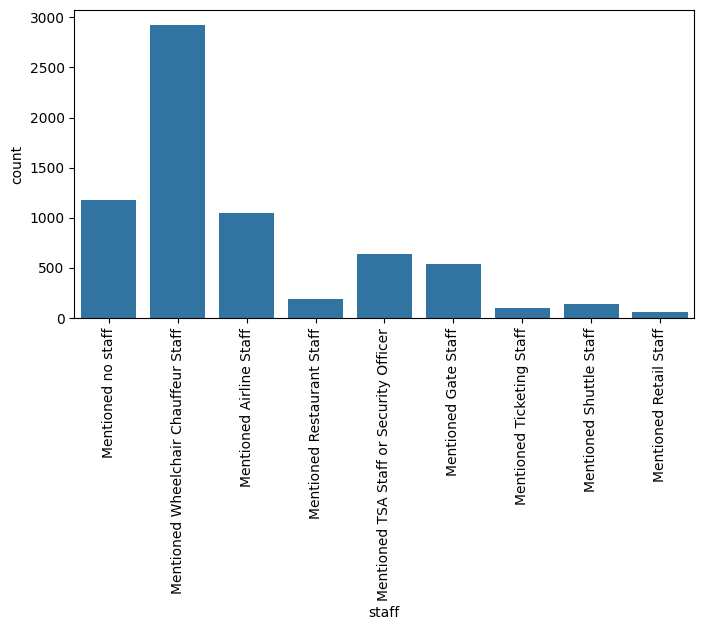

In [194]:
#Count plot of Staff
fig,ax = plt.subplots(1,figsize=(8,4))

sns.countplot(df,x='staff', ax=ax)
plt.xticks(rotation=90)
plt.show()

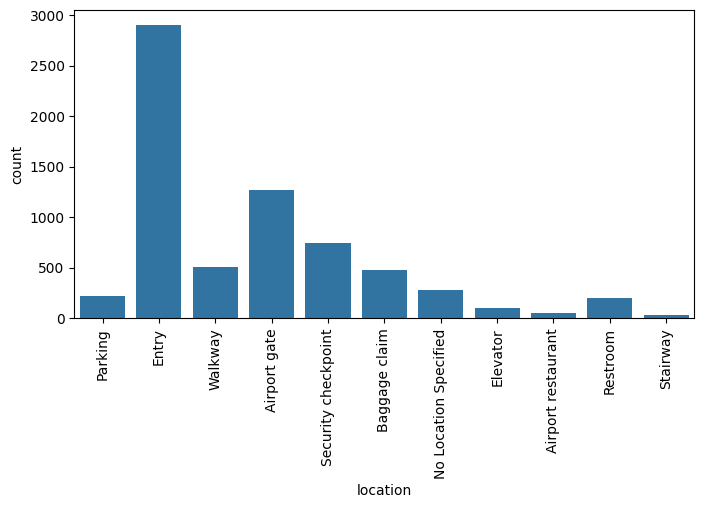

In [195]:
#Count plot of Locations
fig,ax = plt.subplots(1,figsize=(8,4))

sns.countplot(df,x='location', ax=ax)
plt.xticks(rotation=90)
plt.show()

In [196]:
#Determine low review count airports
count_table = df.pivot_table(index='Airport',columns='location',values='Sentiment',aggfunc='count').fillna(0)
count_table['total'] = count_table.sum(axis=1)
count_table.loc['National'] = count_table.sum()

In [197]:
sentiment_table = df.pivot_table(index='Airport',columns='location',values='Sentiment',aggfunc='mean')

sentiment_table.loc['National'] = sentiment_table.mean(axis=0)

sentiment_table = pd.concat([sentiment_table,count_table['total']], axis=1)

sentiment_table = sentiment_table[sentiment_table['total']>100]

In [198]:
sentiment_deviation_table = df.pivot_table(index='Airport',columns='location',values='Sentiment',aggfunc=np.std)

sentiment_deviation_table.loc['National'] = sentiment_deviation_table.mean(axis=0)

sentiment_deviation_table = pd.concat([sentiment_deviation_table,count_table['total']], axis=1)

sentiment_deviation_table = sentiment_deviation_table[sentiment_deviation_table['total']>100]

C:\Users\McCulloughStevenTann\AppData\Local\Temp\ipykernel_23880\1467812431.py:1: FutureWarning: The provided callable <function std at 0x000001EF62683D80> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  sentiment_deviation_table = df.pivot_table(index='Airport',columns='location',values='Sentiment',aggfunc=np.std)


In [199]:
sentiment_deviation_table = " ± " + sentiment_deviation_table.round(2).astype(str)
sentiment_deviation_table[sentiment_deviation_table==" ± nan"] = ""
sentiment_deviation_table['total'] = ''

annotation_table = sentiment_table.round(2).astype(str) + sentiment_deviation_table
annotation_table[annotation_table=="nan"] = np.nan

In [200]:
sentiment_table = sentiment_table[["Parking","Entry","Baggage claim","Security checkpoint","Walkway", "Elevator","Stairway", "Airport restaurant","Restroom",  "Airport gate", "No Location Specified", "total"]]
annotation_table = annotation_table[["Parking","Entry","Baggage claim","Security checkpoint","Walkway", "Elevator","Stairway", "Airport restaurant","Restroom",  "Airport gate", "No Location Specified", "total"]]

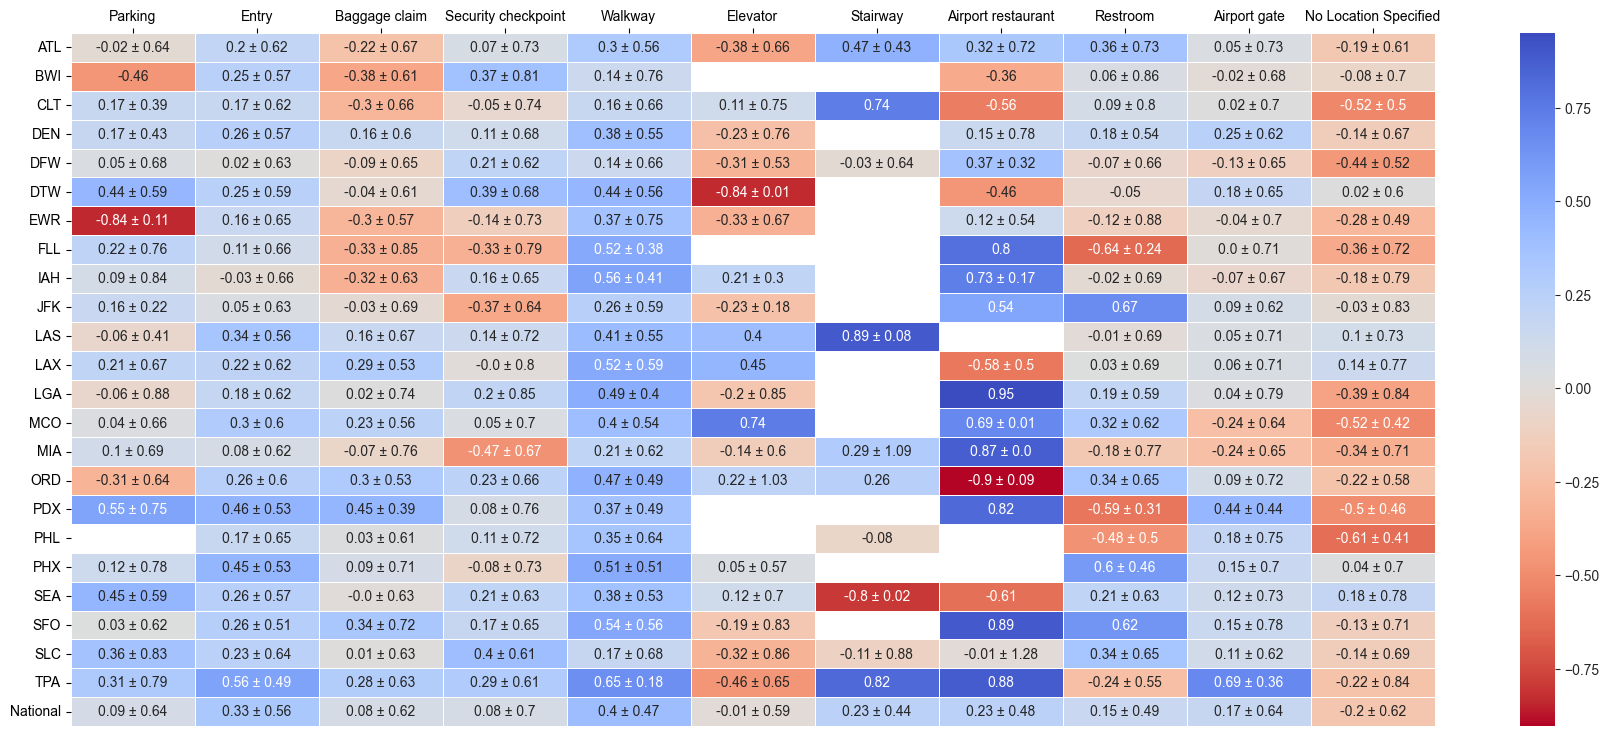

In [201]:
fig,ax = plt.subplots(1,figsize=(22,9))

sns.set_style("white", {'axes.grid' : False})
sns.heatmap(sentiment_table.drop(columns='total'),cmap="coolwarm_r",
            ax=ax,annot=annotation_table.drop(columns='total'),linewidth=.5,fmt ='')

ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()

In [202]:
#Determine low review count airports
count_table = df.pivot_table(index='Airport',columns='staff',values='Sentiment',aggfunc='count').fillna(0)
count_table['total'] = count_table.sum(axis=1)
count_table.loc['National'] = count_table.sum()

In [203]:
sentiment_table = df.pivot_table(index='Airport',columns='staff',values='Sentiment',aggfunc='mean')

sentiment_table.loc['National'] = sentiment_table.mean(axis=0)

sentiment_table = pd.concat([sentiment_table,count_table['total']], axis=1)

sentiment_table = sentiment_table[sentiment_table['total']>100]

In [204]:
sentiment_deviation_table = df.pivot_table(index='Airport',columns='staff',values='Sentiment',aggfunc=np.std)

sentiment_deviation_table.loc['National'] = sentiment_deviation_table.mean(axis=0)

sentiment_deviation_table = pd.concat([sentiment_deviation_table,count_table['total']], axis=1)

sentiment_deviation_table = sentiment_deviation_table[sentiment_deviation_table['total']>100]

C:\Users\McCulloughStevenTann\AppData\Local\Temp\ipykernel_23880\978560500.py:1: FutureWarning: The provided callable <function std at 0x000001EF62683D80> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  sentiment_deviation_table = df.pivot_table(index='Airport',columns='staff',values='Sentiment',aggfunc=np.std)


In [205]:
sentiment_deviation_table = " ± " + sentiment_deviation_table.round(2).astype(str)
sentiment_deviation_table[sentiment_deviation_table==" ± nan"] = ""
sentiment_deviation_table['total'] = ''

annotation_table = sentiment_table.round(2).astype(str) + sentiment_deviation_table
annotation_table[annotation_table=="nan"] = np.nan

In [206]:
sentiment_table = sentiment_table.set_axis(["Airline ","Gate ","Restaurant","Retail","Shuttle", "TSA","Ticketing", "Chauffeur","No Staff Specified","Total"],axis=1)
annotation_table = annotation_table.set_axis(["Airline ","Gate ","Restaurant","Retail","Shuttle", "TSA","Ticketing", "Chauffeur","No Staff Specified","Total"],axis=1)


In [207]:
sentiment_table = sentiment_table[["Chauffeur","Ticketing","TSA","Shuttle","Restaurant","Retail","Gate ","Airline ","No Staff Specified","Total"]]
annotation_table = annotation_table[["Chauffeur","Ticketing","TSA","Shuttle","Restaurant","Retail","Gate ","Airline ","No Staff Specified","Total"]]

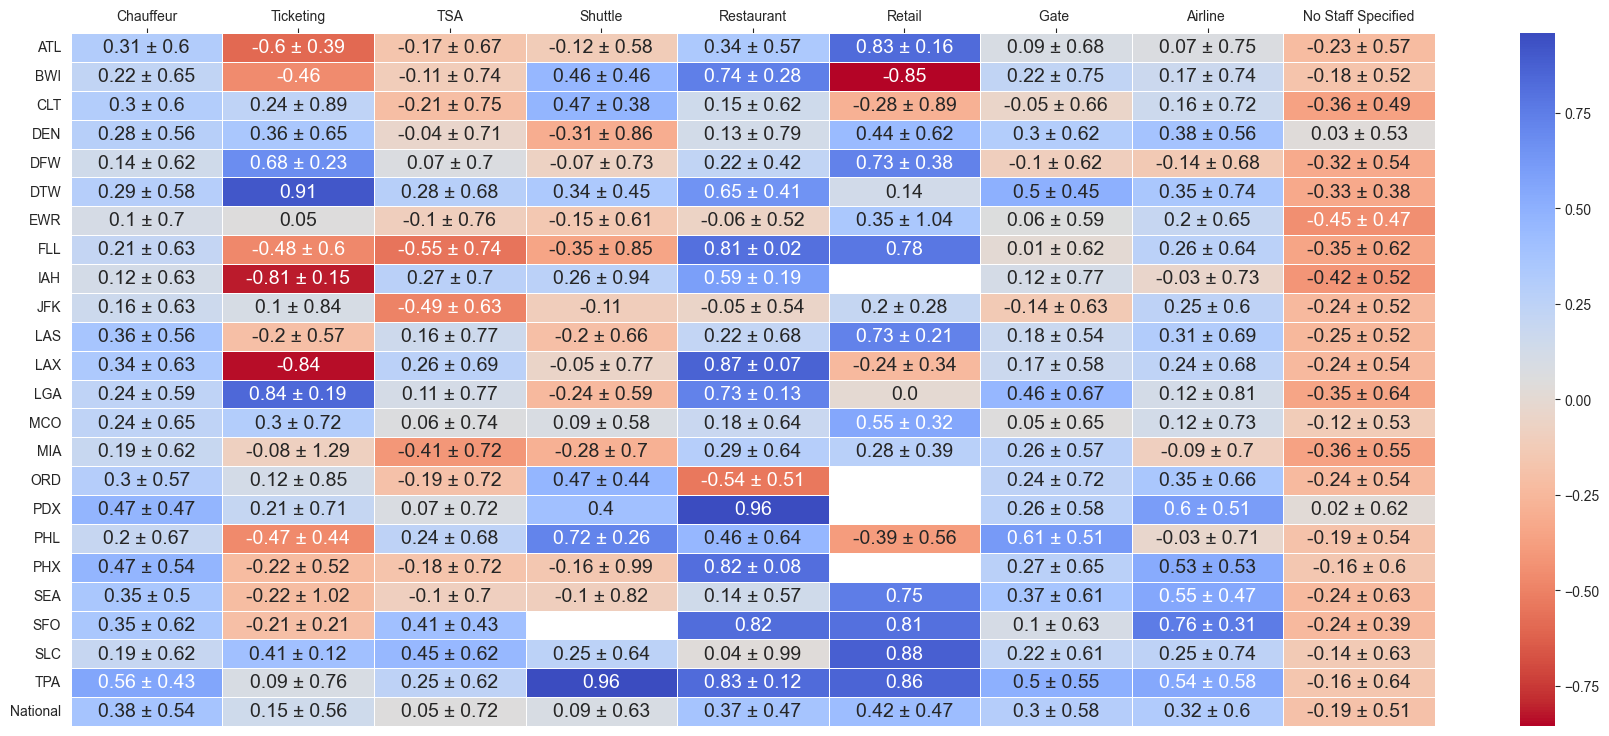

In [208]:
fig,ax = plt.subplots(1,figsize=(22,9))

sns.set_style("white", {'axes.grid' : False})
sns.heatmap(sentiment_table.drop(columns='Total'),cmap="coolwarm_r",
            ax=ax,annot=annotation_table.drop(columns='Total'),linewidth=.5, fmt="",annot_kws={"fontsize":14})

ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()

### Number Plot and Correlations

In [209]:
df = pd.read_csv('first_level_results.csv')
df.loc[df['disability']=='Disability Status Unknown','disability'] = 'Person does not has a disability'
df

,Unnamed: 0.1,Unnamed: 0,Review Text,Score,Date,Airport,disability,disability_confidence,category
0,0,0,Can t afford air conditioning anymore. Always...,3,2024-09-30,ABQ,Person has a disability,0.518916,NaN
1,1,1,Views out the windows os great with the mount...,3,2024-09-30,ABQ,Person has a disability,0.460491,NaN
2,2,2,Airport undergoing renovation yet still mainta...,5,2024-09-30,ABQ,Person does not has a disability,0.536927,NaN
3,3,3,Nice little airport... generally pretty quiet,4,2024-09-30,ABQ,Person does not has a disability,0.484003,NaN
4,4,4,I took my first flight ever from here. Took a ...,5,2024-09-30,ABQ,Person has a disability,0.596495,NaN
...,...,...,...,...,...,...,...,...,...
474216,474216,24618,I have to day that I actually love this airpor...,4,2011-10-11,TPA,Person does not has a disability,0.468524,NaN
474217,474217,24619,This airport makes it a pleasure to fly. Th p...,5,2011-10-11,TPA,Person does not has a disability,0.521146,NaN
474218,474218,24620,What a great airport. Easy to get in and out.,5,2011-10-11,TPA,Person does not has a disability,0.575977,NaN
474219,474219,24622,Early flights are the best. You just cruise th...,5,2011-10-11,TPA,Person does not has a disability,0.499040,NaN


In [210]:
table = pd.pivot_table(df,index='Airport',columns='disability',values='Unnamed: 0',aggfunc='count')
table['Total Posts'] = table.sum(axis=1)
table['% PWD Posts'] = 100*table['Person has a disability']/table['Total Posts']

table=table.sort_index()

table

disability,Person does not has a disability,Person has a disability,Total Posts,% PWD Posts
Airport,,,,
ABQ,1598.0,247.0,1845.0,13.387534
ANC,1355.0,231.0,1586.0,14.564943
ATL,19272.0,3742.0,23014.0,16.259668
AUS,5249.0,831.0,6080.0,13.667763
BDL,1920.0,315.0,2235.0,14.093960
...,...,...,...,...
SLC,8018.0,1492.0,9510.0,15.688749
SMF,3304.0,512.0,3816.0,13.417191
SNA,2975.0,354.0,3329.0,10.633824


In [63]:
meta_df = pd.read_excel('airport_64.xlsx')
meta_df
meta_df=meta_df.set_index('CODE')
meta_df=meta_df.sort_index()
meta_df

,AIRPORT,CITY,STATE,lat,lon,REGION,type,type_detail,GATE,CENSUS_1,CENSUS_2,TSA,POLITIC,PSGR,HUB
CODE,,,,,,,,,,,,,,,
ANC,Ted Stevens Anchorage International,Anchorage,AK,61.174320,-149.996186,AAL,LP,"Linear, Pier",8,west,pacific,19,40.990303,1157378,M
ATL,William B Hartsfield-Atlanta Intl,Atlanta,GA,33.640444,-84.426944,ASO,S,Satellite,195,south,southatlantic,190,19.118561,20559866,L
AUS,Austin-Bergstrom International,Austin,TX,30.194533,-97.669872,ASW,L,Linear,24,south,westsouthcentral,56,21.091362,6288519,L
BDL,Bradley International,Windsor Locks,CT,41.938874,-72.683228,ANE,P,Pier,37,northeast,newengland,34,62.503490,1150033,M
BNA,Nashville International,Nashville,TN,36.124477,-86.678182,ASO,P,Pier,42,south,eastsouthcentral,56,23.999550,4016808,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLC,Salt Lake City Intl,Salt Lake City,UT,40.788388,-111.977773,ANM,P,Pier,71,west,mountain,91,20.113541,5981032,L
SMF,Sacramento International,Sacramento,CA,38.695422,-121.590767,AWP,SP,"Pier, Satellite",40,west,pacific,38,70.384209,2710342,M
SNA,John Wayne Orange Co,Santa Ana,CA,33.675659,-117.868223,AWP,L,Linear,20,west,pacific,35,70.384209,1824836,M


In [64]:
table = table.join(meta_df)

table = table[['% PWD Posts','GATE','PSGR']]
table=table.reset_index()


,Airport,% PWD Posts,GATE,PSGR
0,ABQ,13.387534,NaN,NaN
1,ANC,14.564943,8.0,1157378.0
2,ATL,16.259668,195.0,20559866.0
3,AUS,13.667763,24.0,6288519.0
4,BDL,14.093960,37.0,1150033.0
...,...,...,...,...
59,SLC,15.688749,71.0,5981032.0
60,SMF,13.417191,40.0,2710342.0
61,SNA,10.633824,20.0,1824836.0
62,STL,15.892857,82.0,3035469.0


In [69]:
table['% PWD Posts']

0     13.387534
1     14.564943
2     16.259668
3     13.667763
4     14.093960
        ...    
59    15.688749
60    13.417191
61    10.633824
62    15.892857
63    11.161357
Name: % PWD Posts, Length: 64, dtype: float64

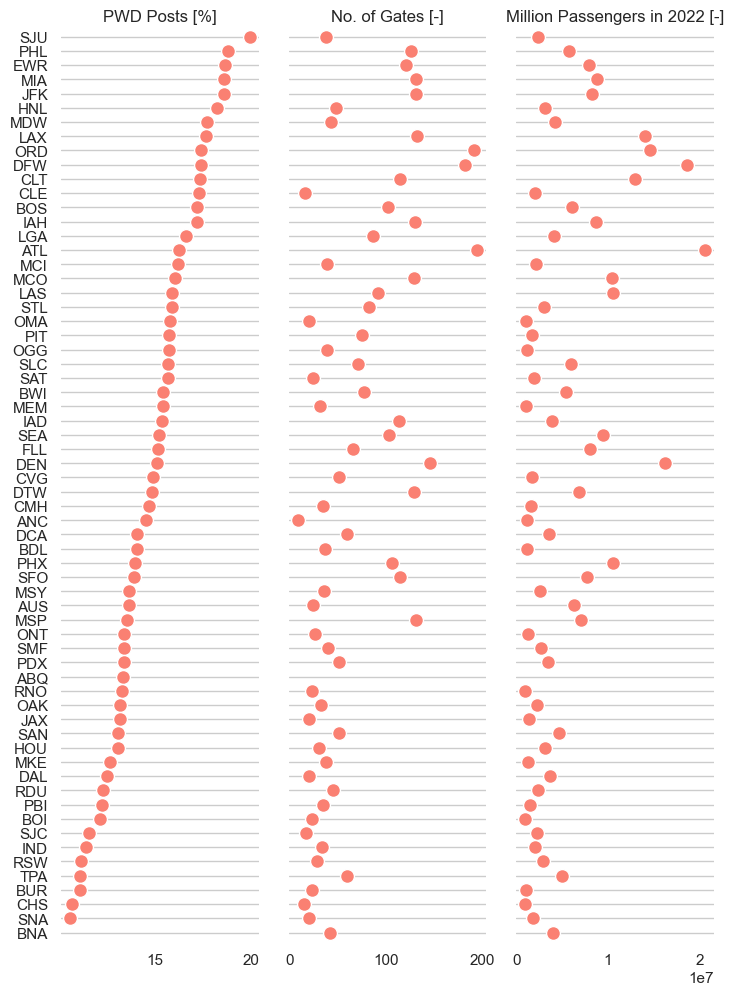

In [79]:

sns.set_theme(style="whitegrid")

# Load the dataset


# Make the PairGrid
g = sns.PairGrid(table.sort_values("% PWD Posts", ascending=False),
                 x_vars=table.columns[-3:], y_vars='Airport',
                 height=10, aspect=.25)

# Draw a dot plot using the stripplot function
g.map(sns.stripplot, size=10, orient="h", jitter=False,
      color="salmon", linewidth=1, edgecolor="w")

# Use the same x axis limits on all columns and add better labels
g.set( xlabel="", ylabel="")

# Use semantically meaningful titles for the columns
titles = ['PWD Posts [%]','No. of Gates [-]','Million Passengers in 2022 [-]']

for ax, title in zip(g.axes.flat, titles):

    # Set a different title for each axes
    ax.set(title=title)

    # Make the grid horizontal instead of vertical
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)
    

sns.despine(left=True, bottom=True)

In [83]:
from scipy.stats import pearsonr

In [88]:
print(pearsonr(table['% PWD Posts'].dropna(), table['GATE'].dropna()))

PearsonRResult(statistic=np.float64(0.5126460890336478), pvalue=np.float64(1.7431071189775364e-05))


In [89]:
print(pearsonr(table['% PWD Posts'].dropna(), table['PSGR'].dropna()))

PearsonRResult(statistic=np.float64(0.409423539998106), pvalue=np.float64(0.0008623273694520962))


### Sankey Creation

In [5]:
from sankeyflow import Sankey
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('fourth_level_results.csv').drop(columns='category')
short_staffs = ['No Staff',
 'Chauffeur',
 'Airline',
 'Restaurant',
 'TSA',
 'Gate',
 'Ticketing',
 'Shuttle',
 'Retail']


locations = df.location.unique().tolist()
staffs = df.staff.unique().tolist()

nodes = []
flows = []

#Create Nodes first
temp_list = []
for i, staff in enumerate(staffs):
    temp_list.append( ( short_staffs[i], len(df[df['staff']==staff]) ) )
nodes.append(temp_list)

#Center Poprtion
nodes.append([('Total',len(df))])

#Location Nodes
temp_list = []
for location in locations:
    temp_list.append( ( location, len(df[df['location']==location]) ) )
nodes.append(temp_list)

#Create Flows
#Staff Flows
temp_list = []
for i, staff in enumerate(staffs):
    flows.append( ( short_staffs[i],'Total', len(df[df['staff']==staff]) ) )

#Location Flows
temp_list = []
for location in locations:
    flows.append( ( 'Total',location, len(df[df['location']==location]) ) )


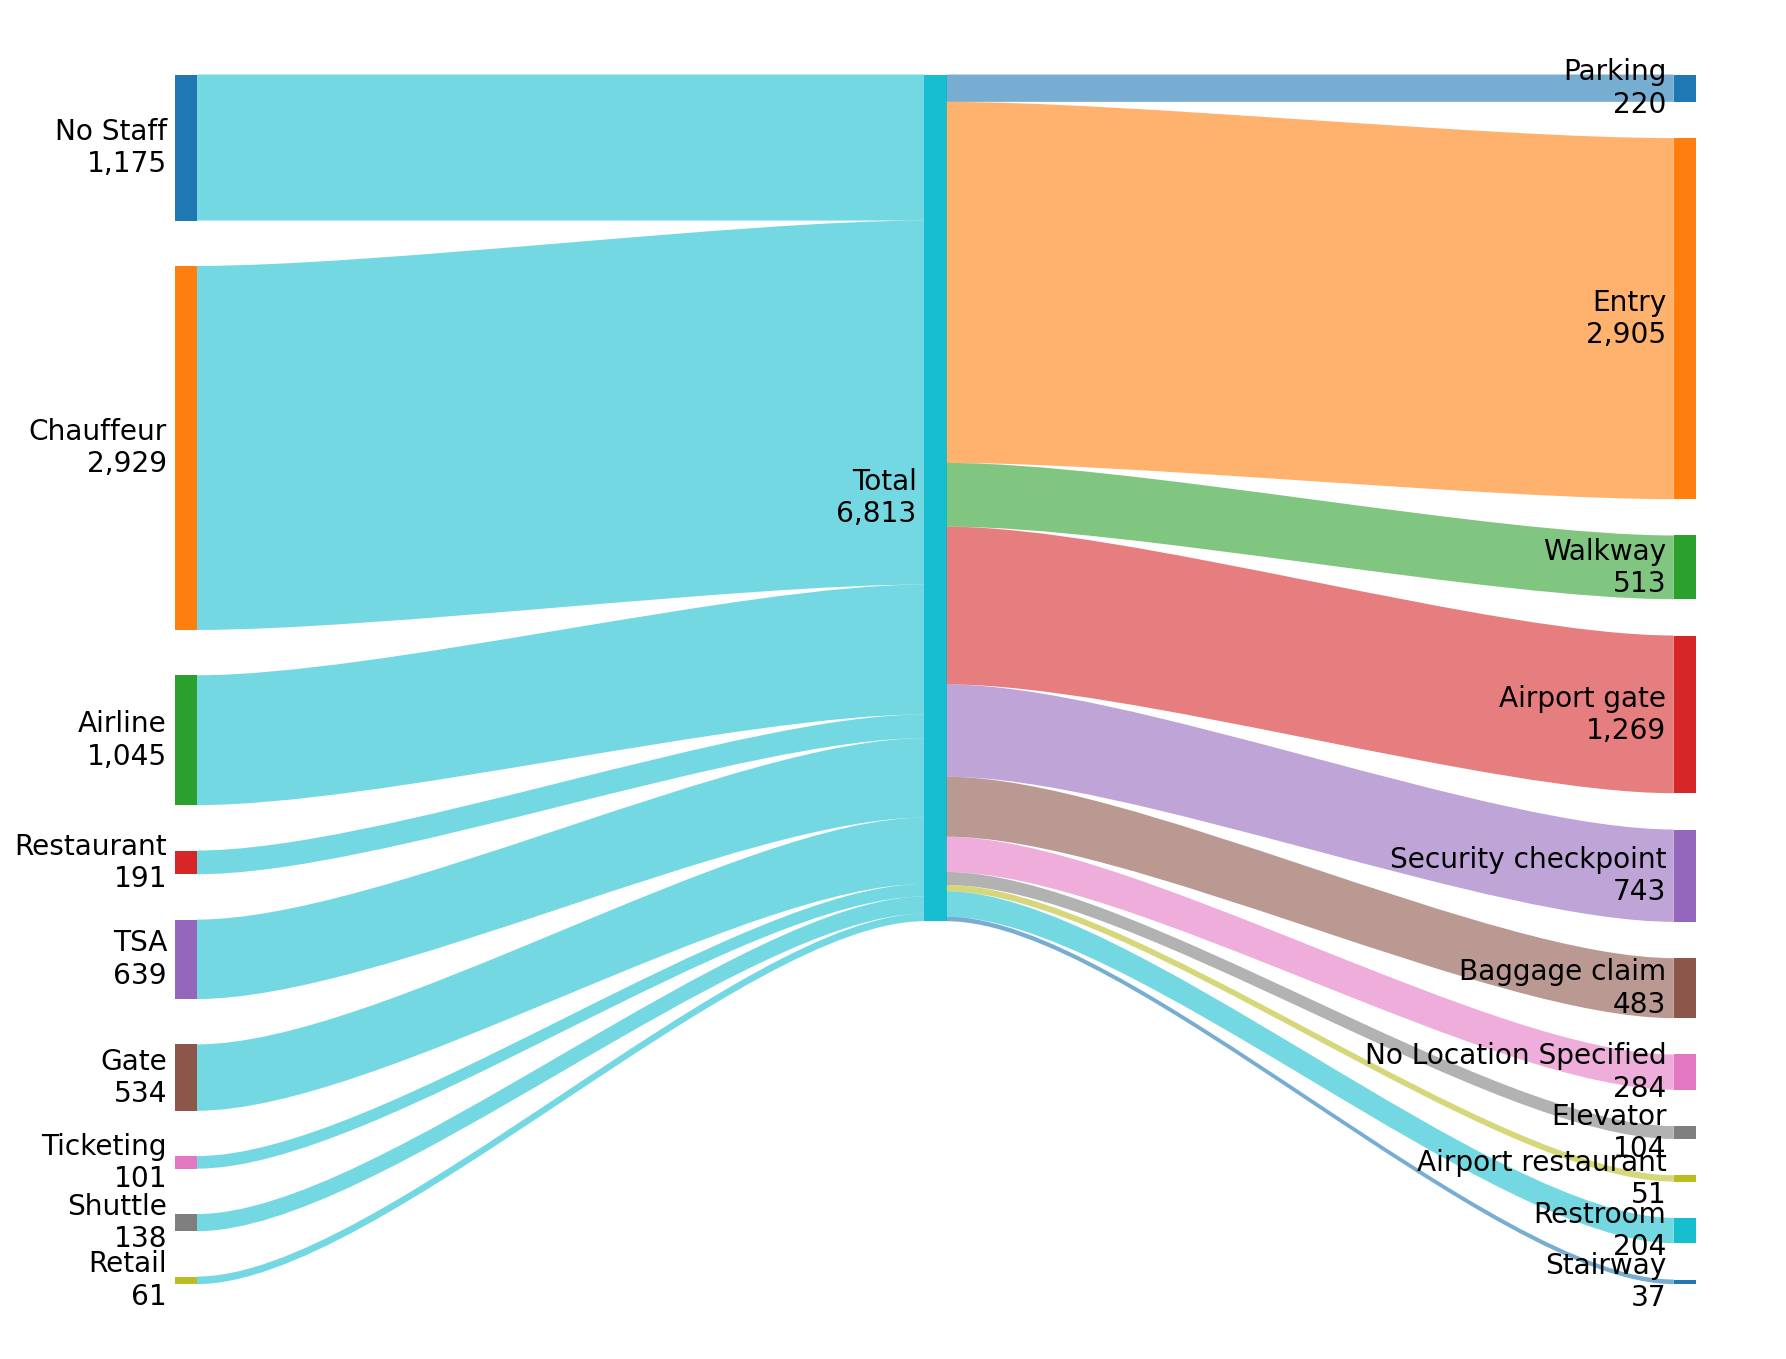

In [7]:
plt.figure(figsize=(15, 12), dpi=144)


s = Sankey(
    flows=flows,
    nodes=nodes,
    flow_opts=dict(curvature=0.25),
    node_pad_y_min=0.03
)

plt.tight_layout()
s.draw()
plt.show()

In [223]:
df[df["staff"]=="Mentioned no staff"].sample()['Review Text'].values

array(['My husband and I had the worst experience at the Dallas Airport! My husband is disabled and there was no wheelchair to meet him at the gate as promised. I went around begging for one for over 30 minutes before finally finding an available one. Less than 5 minutes after finding one an airport employee came to take it for passengers needing to leave another plane. It s such a bummer that disabled passengers do not get the  luxury  of going to the bathroom, moving, or finding food like the able-bodied passengers. To all other disabled patrons: Always have your own wheelchair delivered at the gate during layovers as the Dallas Airport does not provide basic necessities for their disabled patrons.'],
      dtype=object)